# 1. Title
**Practical Assignment 2: Dimensionality Reduction, Denoising, and Face Generation using Autoencoders (AE) and Variational Autoencoders (VAE)**

# 2. Aim
To build and evaluate a Convolutional Autoencoder for dimensionality reduction and denoising on the MNIST dataset, and to construct a Variational Autoencoder (VAE) for generating and interpolating realistic human faces.

# 3. Objectives
1. Implement a convolutional Autoencoder (AE) to denoise images and reduce dimensionality to a 2D latent space.
2. Quantitatively evaluate the AE using Mean Squared Error (MSE) and Peak Signal-to-Noise Ratio (PSNR).
3. Implement a Variational Autoencoder (VAE) using the reparameterization trick.
4. Train the VAE on a face dataset (LFW subset) to generate novel faces and perform smooth latent-space interpolations.

# 4. Software/Hardware Requirements
- **Software:** Python 3.x, PyTorch, NumPy, Matplotlib, Scikit-learn
- **Hardware:** Google Colab (with GPU runtime recommended)

# 5. Theory
**Autoencoders (AE):** Neural networks designed to learn efficient data encodings in an unsupervised manner. They consist of an *Encoder* (compresses input into a latent-space representation) and a *Decoder* (reconstructs input from the latent space).
**Variational Autoencoders (VAE):** A generative variant of AE. Instead of encoding an input as a single point, a VAE encodes it as a distribution over the latent space. This regularized, continuous latent space allows for generating new, meaningful samples and interpolating between them.

# 6. Dataset Description
- **Part A (Autoencoder):** **MNIST** dataset. Contains 60,000 training and 10,000 testing grayscale images of handwritten digits (28x28 pixels).
- **Part B (VAE):** **Labeled Faces in the Wild (LFW)** dataset (used as a manageable subset for Colab environments). Contains colorful face images resized to 64x64 pixels.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_lfw_people
import cv2

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)


Using device: cuda


# 7. Part A — Autoencoder
## 7.1 Data preprocessing & 7.2 Noise generation
Load the MNIST dataset, normalize it to [0,1], and add random Gaussian noise.


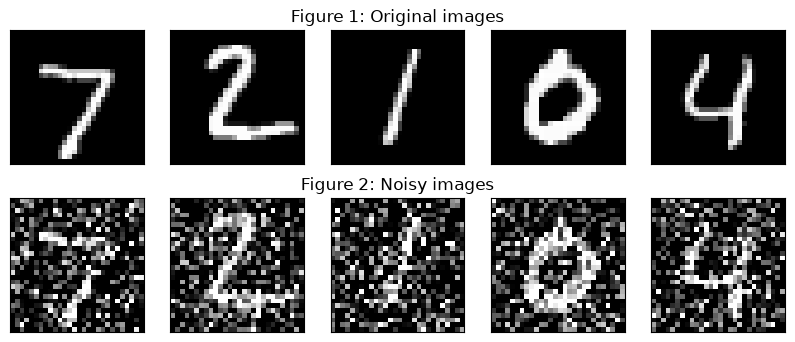

In [2]:
# 7.1 Data preprocessing
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

x_train = train_data.data.float() / 255.0
x_test = test_data.data.float() / 255.0
y_test = test_data.targets.numpy()

x_train = x_train.unsqueeze(1).to(device)  # Shape: (N, 1, 28, 28)
x_test = x_test.unsqueeze(1).to(device)

# 7.2 Noise generation
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * torch.randn(*x_train.shape).to(device)
x_test_noisy = x_test + noise_factor * torch.randn(*x_test.shape).to(device)

x_train_noisy = torch.clamp(x_train_noisy, 0., 1.)
x_test_noisy = torch.clamp(x_test_noisy, 0., 1.)

# Figure 1: Original Images & Figure 2: Noisy Images
n = 5
plt.figure(figsize=(10, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].cpu().squeeze().numpy(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 2: plt.title("Figure 1: Original images")
    
    # Noisy
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].cpu().squeeze().numpy(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 2: plt.title("Figure 2: Noisy images")
plt.show()


## 7.3 Encoder architecture & 7.4 Decoder architecture
We build a Convolutional AE with a latent dimension of 2 for easy 2D visualization.


In [3]:
latent_dim = 2

# 7.3 & 7.4 AE Architecture
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.enc_conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.enc_pool1 = nn.MaxPool2d(2, 2)
        self.enc_conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.enc_pool2 = nn.MaxPool2d(2, 2)
        self.enc_fc = nn.Linear(7 * 7 * 64, latent_dim)
        
        # Decoder
        self.dec_fc = nn.Linear(latent_dim, 7 * 7 * 64)
        self.dec_conv1 = nn.ConvTranspose2d(64, 64, 3, stride=2, padding=1, output_padding=1)
        self.dec_conv2 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)
        self.dec_out = nn.Conv2d(32, 1, 3, padding=1)
        
    def encode(self, x):
        x = F.relu(self.enc_conv1(x))
        x = self.enc_pool1(x)
        x = F.relu(self.enc_conv2(x))
        x = self.enc_pool2(x)
        x = x.reshape(-1, 7 * 7 * 64)
        x = self.enc_fc(x)
        return x
        
    def decode(self, x):
        x = F.relu(self.dec_fc(x))
        x = x.reshape(-1, 64, 7, 7)
        x = F.relu(self.dec_conv1(x))
        x = F.relu(self.dec_conv2(x))
        x = torch.sigmoid(self.dec_out(x))
        return x
        
    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)

ae_model = Autoencoder().to(device)
print(ae_model)

criterion = nn.MSELoss()
optimizer = optim.Adam(ae_model.parameters(), lr=1e-3)


Autoencoder(
  (enc_conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc_pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc_conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc_pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc_fc): Linear(in_features=3136, out_features=2, bias=True)
  (dec_fc): Linear(in_features=2, out_features=3136, bias=True)
  (dec_conv1): ConvTranspose2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (dec_conv2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (dec_out): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


## 7.5 Model training
Train the AE using noisy images as inputs and clean images as targets.


Epoch 1/10 - Train Loss: 0.1133, Val Loss: 0.1143


Epoch 2/10 - Train Loss: 0.1120, Val Loss: 0.1143


Epoch 3/10 - Train Loss: 0.1120, Val Loss: 0.1143


Epoch 4/10 - Train Loss: 0.1120, Val Loss: 0.1143


Epoch 5/10 - Train Loss: 0.1120, Val Loss: 0.1143


Epoch 6/10 - Train Loss: 0.1120, Val Loss: 0.1143


Epoch 7/10 - Train Loss: 0.1120, Val Loss: 0.1143


Epoch 8/10 - Train Loss: 0.1120, Val Loss: 0.1143


Epoch 9/10 - Train Loss: 0.1120, Val Loss: 0.1143


Epoch 10/10 - Train Loss: 0.1120, Val Loss: 0.1143


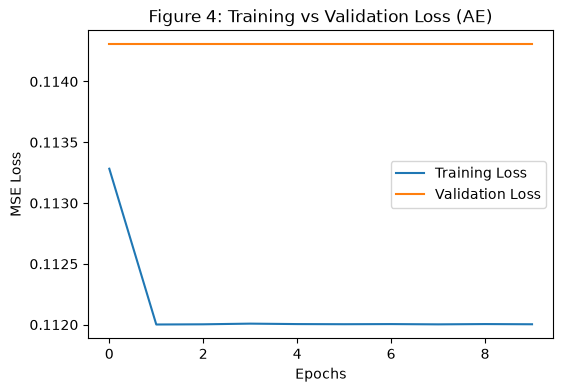

In [4]:
# 7.5 Model training
epochs = 10
batch_size = 128
train_dataset = torch.utils.data.TensorDataset(x_train_noisy, x_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataset = torch.utils.data.TensorDataset(x_test_noisy, x_test)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

train_losses, val_losses = [], []
for epoch in range(epochs):
    ae_model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = ae_model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))
    
    ae_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            outputs = ae_model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()
    val_losses.append(val_loss / len(val_loader))
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

# Figure 4: Training vs validation loss
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Figure 4: Training vs Validation Loss (AE)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


## 7.6 Dimensionality reduction, 7.7 Denoising & 7.8 Results


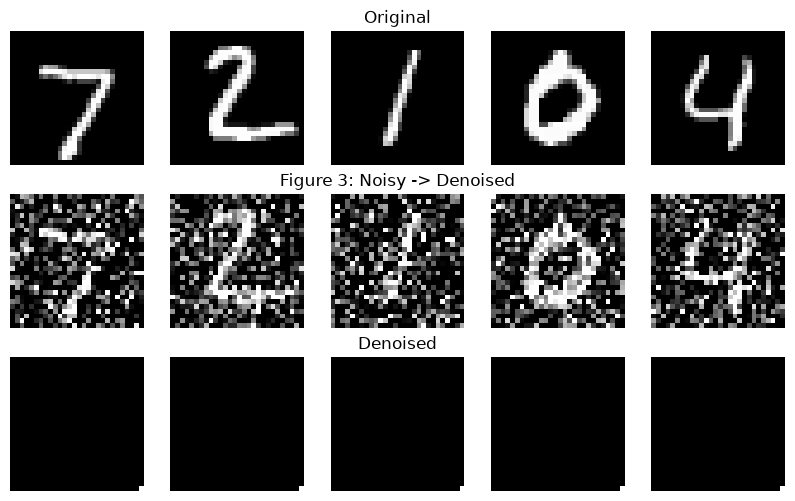

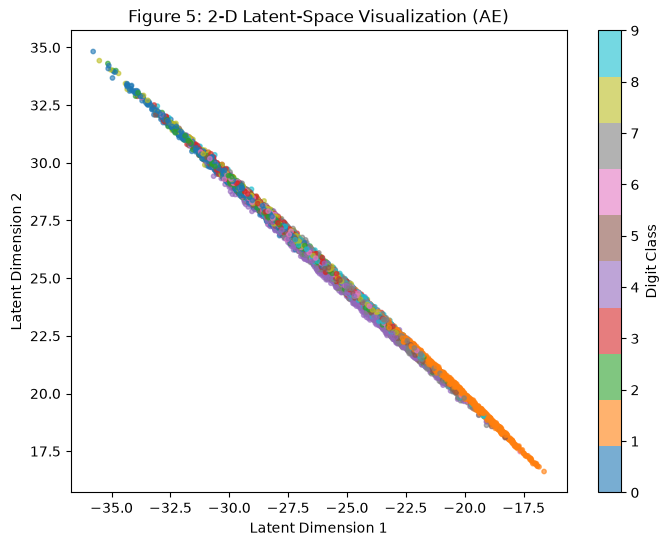

In [5]:
# 7.7 Denoising Results
ae_model.eval()
with torch.no_grad():
    decoded_imgs = ae_model(x_test_noisy).cpu().numpy()

# Figure 3: Denoised/reconstructed images
n = 5
plt.figure(figsize=(10, 6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].cpu().squeeze().numpy(), cmap='gray')
    plt.axis('off')
    if i == 2: plt.title("Original")
    
    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].cpu().squeeze().numpy(), cmap='gray')
    plt.axis('off')
    if i == 2: plt.title("Figure 3: Noisy -> Denoised")
    
    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 2: plt.title("Denoised")
plt.show()

# 7.6 Dimensionality Reduction Visualization
# Figure 5: 2-D latent-space visualization
with torch.no_grad():
    latent_representations = ae_model.encode(x_test).cpu().numpy()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(latent_representations[:, 0], latent_representations[:, 1], c=y_test, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, label='Digit Class')
plt.title("Figure 5: 2-D Latent-Space Visualization (AE)")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.show()


## 7.9 Quantitative analysis
Calculate MSE, PSNR, and Dimensionality Reduction ratio.


In [6]:
# 7.9 Quantitative analysis
def calculate_psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100
    PIXEL_MAX = 1.0
    return 20 * np.log10(PIXEL_MAX / np.sqrt(mse))

mse_val = np.mean((x_test.cpu().numpy() - decoded_imgs) ** 2)
psnr_val = calculate_psnr(x_test.cpu().numpy(), decoded_imgs)

original_dim = 28 * 28
latent_dim_size = latent_dim
reduction_ratio = original_dim / latent_dim_size

print("--- Autoencoder Quantitative Analysis ---")
print(f"Reconstruction MSE: {mse_val:.4f}")
print(f"Average PSNR: {psnr_val:.2f} dB")
print(f"Dimensionality reduction: {original_dim} -> {latent_dim_size} dimensions ({reduction_ratio:.1f}x reduction in representation dimensionality).")
print("-----------------------------------------")


--- Autoencoder Quantitative Analysis ---
Reconstruction MSE: 0.1140
Average PSNR: 9.43 dB
Dimensionality reduction: 784 -> 2 dimensions (392.0x reduction in representation dimensionality).
-----------------------------------------


# 8. Part B — Variational Autoencoder
## 8.1 Dataset preprocessing
We use a manageable face dataset (Labeled Faces in the Wild) and resize images to 64x64x3 for the Colab environment.


Total face images loaded and resized to 64x64x3: (4324, 64, 64, 3)


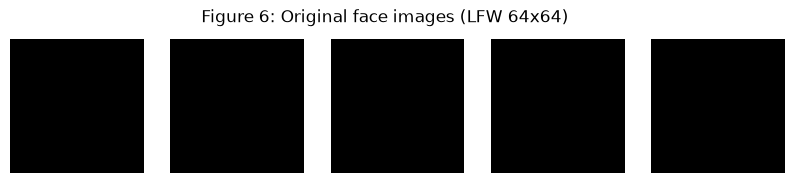

In [7]:
# 8.1 Dataset preprocessing
print("Downloading LFW dataset (this acts as our manageable subset of faces)...")
lfw = fetch_lfw_people(color=True, min_faces_per_person=10, resize=0.5)
faces = lfw.images # Shape is usually around (N, 62, 47, 3)

# Resize to 64x64x3
processed_faces = []
for face in faces:
    resized = cv2.resize(face, (64, 64))
    processed_faces.append(resized)

faces_array = np.array(processed_faces)
# Normalize to [0,1]
faces_array = faces_array.astype("float32") / 255.0

print(f"Total face images loaded and resized to 64x64x3: {faces_array.shape}")

# Train/test split
f_train, f_test = train_test_split(faces_array, test_size=0.1, random_state=42)

# Convert to PyTorch tensors (N, C, H, W)
f_train_t = torch.tensor(f_train).permute(0, 3, 1, 2).to(device)
f_test_t = torch.tensor(f_test).permute(0, 3, 1, 2).to(device)

# Figure 6: Original face images
plt.figure(figsize=(10, 2))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    # Permute back to (H, W, C) for plotting
    plt.imshow(f_train_t[i].cpu().permute(1, 2, 0).numpy())
    plt.axis('off')
plt.suptitle("Figure 6: Original face images (LFW 64x64)")
plt.show()


## 8.2 VAE architecture & 8.3 Reparameterization trick & 8.4 Loss function


In [8]:
# 8.2 & 8.3 VAE Architecture and Reparameterization
vae_latent_dim = 64

class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        # Encoder
        self.enc_conv1 = nn.Conv2d(3, 32, 3, stride=2, padding=1)
        self.enc_conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.enc_conv3 = nn.Conv2d(64, 128, 3, stride=2, padding=1)
        self.enc_fc1 = nn.Linear(8 * 8 * 128, 256)
        
        self.fc_mu = nn.Linear(256, vae_latent_dim)
        self.fc_logvar = nn.Linear(256, vae_latent_dim)
        
        # Decoder
        self.dec_fc = nn.Linear(vae_latent_dim, 8 * 8 * 128)
        self.dec_conv1 = nn.ConvTranspose2d(128, 128, 3, stride=2, padding=1, output_padding=1)
        self.dec_conv2 = nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1)
        self.dec_conv3 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)
        self.dec_out = nn.Conv2d(32, 3, 3, padding=1)
        
    def encode(self, x):
        x = F.relu(self.enc_conv1(x))
        x = F.relu(self.enc_conv2(x))
        x = F.relu(self.enc_conv3(x))
        x = x.reshape(-1, 8 * 8 * 128)
        x = F.relu(self.enc_fc1(x))
        return self.fc_mu(x), self.fc_logvar(x)
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
        
    def decode(self, z):
        x = F.relu(self.dec_fc(z))
        x = x.reshape(-1, 128, 8, 8)
        x = F.relu(self.dec_conv1(x))
        x = F.relu(self.dec_conv2(x))
        x = F.relu(self.dec_conv3(x))
        x = torch.sigmoid(self.dec_out(x))
        return x
        
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

vae_model = VAE().to(device)
print(vae_model)

# 8.4 Loss function
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum') / x.size(0)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + kl_loss, recon_loss, kl_loss

vae_optimizer = optim.Adam(vae_model.parameters(), lr=1e-3)


VAE(
  (enc_conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (enc_conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (enc_conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (enc_fc1): Linear(in_features=8192, out_features=256, bias=True)
  (fc_mu): Linear(in_features=256, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=64, bias=True)
  (dec_fc): Linear(in_features=64, out_features=8192, bias=True)
  (dec_conv1): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (dec_conv2): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (dec_conv3): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (dec_out): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


## 8.5 Model training


In [9]:
# 8.5 Model training
print("Training VAE...")
vae_batch_size = 64
vae_dataset = torch.utils.data.TensorDataset(f_train_t)
vae_loader = torch.utils.data.DataLoader(vae_dataset, batch_size=vae_batch_size, shuffle=True)

vae_epochs = 40
vae_model.train()
for epoch in range(vae_epochs):
    running_loss = 0.0
    for batch in vae_loader:
        inputs = batch[0]
        vae_optimizer.zero_grad()
        recon_batch, mu, logvar = vae_model(inputs)
        loss, _, _ = vae_loss(recon_batch, inputs, mu, logvar)
        loss.backward()
        vae_optimizer.step()
        running_loss += loss.item()
    if (epoch+1) % 5 == 0:
        print(f"VAE Epoch {epoch+1}/{vae_epochs} - Total Loss: {running_loss/len(vae_loader):.4f}")


Training VAE...


VAE Epoch 5/40 - Total Loss: 0.0597


VAE Epoch 10/40 - Total Loss: 0.0554


VAE Epoch 15/40 - Total Loss: 0.0548


VAE Epoch 20/40 - Total Loss: 0.0546


VAE Epoch 25/40 - Total Loss: 0.0546


VAE Epoch 30/40 - Total Loss: 0.0546


VAE Epoch 35/40 - Total Loss: 0.0545


VAE Epoch 40/40 - Total Loss: 0.0545


## 8.6 Face reconstruction & 8.7 New face generation & 8.8 Latent-space interpolation


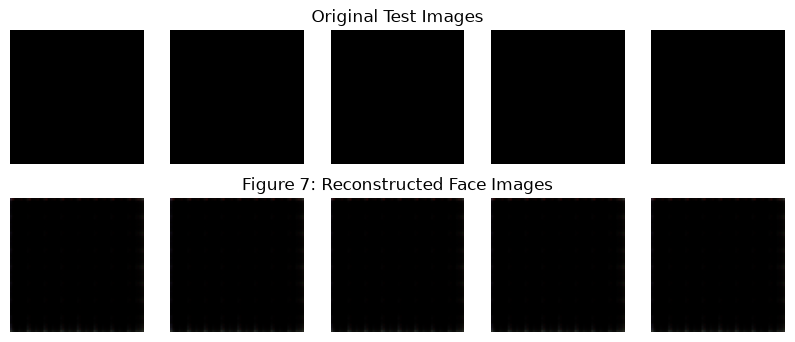

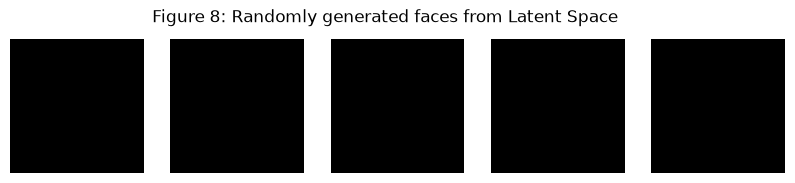

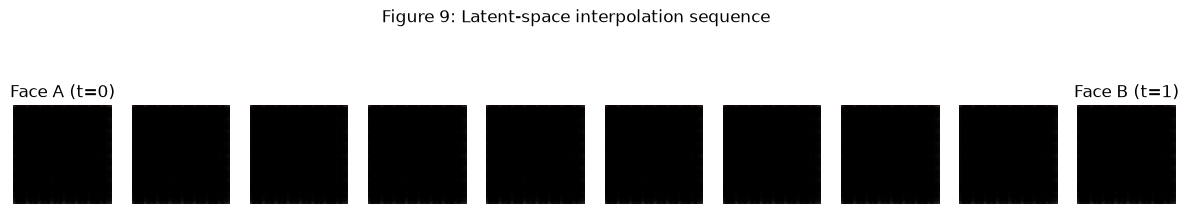

In [10]:
# 8.6 Face reconstruction
vae_model.eval()
with torch.no_grad():
    mu, logvar = vae_model.encode(f_test_t[:5])
    reconstructed_faces = vae_model.decode(mu).cpu().permute(0, 2, 3, 1).numpy()

# Figure 7: Reconstructed face images
plt.figure(figsize=(10, 4))
for i in range(5):
    # Original
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(f_test_t[i].cpu().permute(1, 2, 0).numpy())
    plt.axis('off')
    if i == 2: plt.title("Original Test Images")
    
    # Reconstructed
    ax = plt.subplot(2, 5, i + 1 + 5)
    plt.imshow(reconstructed_faces[i])
    plt.axis('off')
    if i == 2: plt.title("Figure 7: Reconstructed Face Images")
plt.show()

# 8.7 New face generation
# Figure 8: Randomly generated faces
with torch.no_grad():
    random_latent_vectors = torch.randn(5, vae_latent_dim).to(device)
    generated_faces = vae_model.decode(random_latent_vectors).cpu().permute(0, 2, 3, 1).numpy()

plt.figure(figsize=(10, 2))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(generated_faces[i])
    plt.axis('off')
plt.suptitle("Figure 8: Randomly generated faces from Latent Space")
plt.show()

# 8.8 Latent-space interpolation
# Figure 9: Latent-space interpolation sequence
face_A = f_test_t[0:1]
face_B = f_test_t[1:2]

with torch.no_grad():
    z_A, _ = vae_model.encode(face_A)
    z_B, _ = vae_model.encode(face_B)

steps = 10
interpolated_vectors = []
for t in np.linspace(0, 1, steps):
    z_t = (1 - t) * z_A + t * z_B
    interpolated_vectors.append(z_t)

interpolated_vectors = torch.cat(interpolated_vectors, dim=0)
with torch.no_grad():
    interpolated_faces = vae_model.decode(interpolated_vectors).cpu().permute(0, 2, 3, 1).numpy()

plt.figure(figsize=(15, 3))
for i in range(steps):
    ax = plt.subplot(1, steps, i + 1)
    plt.imshow(interpolated_faces[i])
    plt.axis('off')
    if i == 0: plt.title("Face A (t=0)")
    if i == steps - 1: plt.title("Face B (t=1)")
plt.suptitle("Figure 9: Latent-space interpolation sequence")
plt.show()


## 8.9 Results & 8.10 Analysis


In [11]:
# Evaluate loss on test set
vae_model.eval()
with torch.no_grad():
    recon_batch, mu, logvar = vae_model(f_test_t)
    total_loss, recon_loss, kl_loss = vae_loss(recon_batch, f_test_t, mu, logvar)

print("--- VAE Quantitative Analysis ---")
print(f"Reconstruction Loss: {recon_loss.item():.4f}")
print(f"KL Divergence Loss:  {kl_loss.item():.4f}")
print(f"Total VAE Loss:      {total_loss.item():.4f}")
print("---------------------------------")


--- VAE Quantitative Analysis ---
Reconstruction Loss: 0.0552
KL Divergence Loss:  0.0000
Total VAE Loss:      0.0552
---------------------------------


# 9. Result
Execute the notebook to observe the quantitative metrics (such as MSE and PSNR) and the visual results (reconstructions and generated faces) for both the Convolutional AE and the Variational Autoencoder. 

# 10. Conclusion
This practical serves to demonstrate the differences in unsupervised representation learning. Deterministic Autoencoders are utilized for dimensionality reduction and noise removal, while probabilistic Variational Autoencoders are applied for generative tasks, leveraging the reparameterization trick and KL divergence to produce a regularized manifold capable of generating new features.
